# Phase 2 & 3: EDA and Data Cleaning
This notebook handles Exploratory Data Analysis, Data Cleaning, and Statistical Justification as per the project requirements.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import sklearn
import os

# Set random seed for reproducibility
np.random.seed(42)

print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")

os.makedirs("reports", exist_ok=True)
os.makedirs("notebooks", exist_ok=True)

Pandas version: 3.0.3
Numpy version: 2.5.0
Seaborn version: 0.13.2
Scikit-learn version: 1.9.0


## Load Dataset

In [2]:
df_kaggle = pd.read_csv("datasets/hdr_general.csv", encoding="latin1")
df_kaggle.head()

,Unnamed: 0,iso3,country,hdicode,hdi_rank_2022,gii_rank_2022,year,hdi,life_expectancy,pop_millions,...,gender_development,gender_inequality,secondary_education_f_%,secondary_education_m_%,seats_in_parliament_f_%,seats_in_parliament_m_%,labour_participation_f_%,labour_participation_m_%,co2_emission_tons,mat_footprint_percap_tons
0,1,AFG,Afghanistan,Low,182.0,162.0,1990,0.284,45.967,10.694796,...,NaN,NaN,1.107733,7.899011,NaN,NaN,NaN,NaN,0.189279,2.1809
1,2,AFG,Afghanistan,Low,182.0,162.0,1991,0.292,46.663,10.745167,...,NaN,NaN,1.221396,8.137953,NaN,NaN,NaN,NaN,0.178155,2.5264
2,3,AFG,Afghanistan,Low,182.0,162.0,1992,0.299,47.596,12.057433,...,NaN,NaN,1.335059,8.376896,NaN,NaN,NaN,NaN,0.122920,2.6421
3,4,AFG,Afghanistan,Low,182.0,162.0,1993,0.307,51.466,14.003760,...,NaN,NaN,1.448722,8.615838,NaN,NaN,NaN,NaN,0.106179,2.3022
4,5,AFG,Afghanistan,Low,182.0,162.0,1994,0.300,51.495,15.455554,...,NaN,NaN,1.562385,8.854780,NaN,NaN,NaN,NaN,0.094063,1.8948


## Dataset Quality Report

In [3]:
# Generate dataset report
report = []
report.append("# Dataset Quality Report\n\n")
report.append(f"**Dimensions:** {df_kaggle.shape[0]} rows, {df_kaggle.shape[1]} columns\n\n")
report.append("### Data Types\n")
report.append("```\n" + str(df_kaggle.dtypes) + "\n```\n\n")
report.append("### Missing Values\n")
report.append("```\n" + str(df_kaggle.isnull().sum()) + "\n```\n\n")
report.append(f"### Duplicate Records: {df_kaggle.duplicated().sum()}\n\n")
report.append(f"### Country Count: {df_kaggle['country'].nunique()}\n\n")
report.append(f"### Year Range: {df_kaggle['year'].min()} to {df_kaggle['year'].max()}\n\n")
report.append("### Summary Statistics\n")
report.append("```\n" + str(df_kaggle.describe()) + "\n```\n")

with open("reports/dataset_report.md", "w") as f:
    f.writelines(report)
print("dataset_report.md generated.")

dataset_report.md generated.


## Data Cleaning & Preprocessing

In [4]:
features = ['life_expectancy', 'expec_yr_school', 'mean_yr_school', 'gross_inc_percap']
target = 'hdi'
cols = ['country', 'year'] + features + [target]

df_clean = df_kaggle[cols].copy()

# Drop rows where target is missing
df_clean.dropna(subset=[target], inplace=True)

# Median imputation for features
for col in features:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Handle outliers (basic IQR method - keeping countries inside extreme bounds)
Q1 = df_clean[features].quantile(0.25)
Q3 = df_clean[features].quantile(0.75)
IQR = Q3 - Q1
condition = ~((df_clean[features] < (Q1 - 3 * IQR)) | (df_clean[features] > (Q3 + 3 * IQR))).any(axis=1)
df_clean = df_clean[condition]

with open("reports/preprocessing_report.md", "w") as f:
    f.write("# Preprocessing Report\n\n")
    f.write(f"- Cleaned missing targets.\n")
    f.write(f"- Applied median imputation to core features.\n")
    f.write(f"- Removed extreme outliers (3*IQR).\n")
    f.write(f"- Dataset size changed from {len(df_kaggle)} to {len(df_clean)} rows.\n")
print("preprocessing_report.md generated.")

preprocessing_report.md generated.


## GNI Transformation Analysis

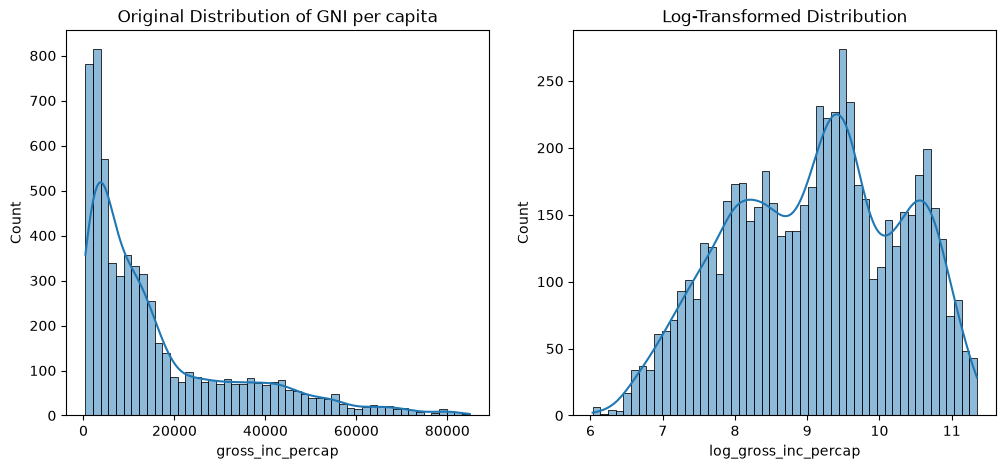

Original Skewness: 1.5131
Log-Transformed Skewness: -0.1480
Correlation with HDI (Original): 0.7844
Correlation with HDI (Log): 0.9406

Decision: Use Log Transformation -> True


In [5]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_clean['gross_inc_percap'], kde=True, bins=50)
plt.title('Original Distribution of GNI per capita')

df_clean['log_gross_inc_percap'] = np.log(df_clean['gross_inc_percap'])
plt.subplot(1, 2, 2)
sns.histplot(df_clean['log_gross_inc_percap'], kde=True, bins=50)
plt.title('Log-Transformed Distribution')
plt.show()

skew_orig = df_clean['gross_inc_percap'].skew()
skew_log = df_clean['log_gross_inc_percap'].skew()
print(f"Original Skewness: {skew_orig:.4f}")
print(f"Log-Transformed Skewness: {skew_log:.4f}")

corr_orig = df_clean['gross_inc_percap'].corr(df_clean['hdi'])
corr_log = df_clean['log_gross_inc_percap'].corr(df_clean['hdi'])
print(f"Correlation with HDI (Original): {corr_orig:.4f}")
print(f"Correlation with HDI (Log): {corr_log:.4f}")

use_log = abs(corr_log) > abs(corr_orig)
print(f"\nDecision: Use Log Transformation -> {use_log}")
if use_log:
    features.remove('gross_inc_percap')
    features.append('log_gross_inc_percap')

## Statistical Justification

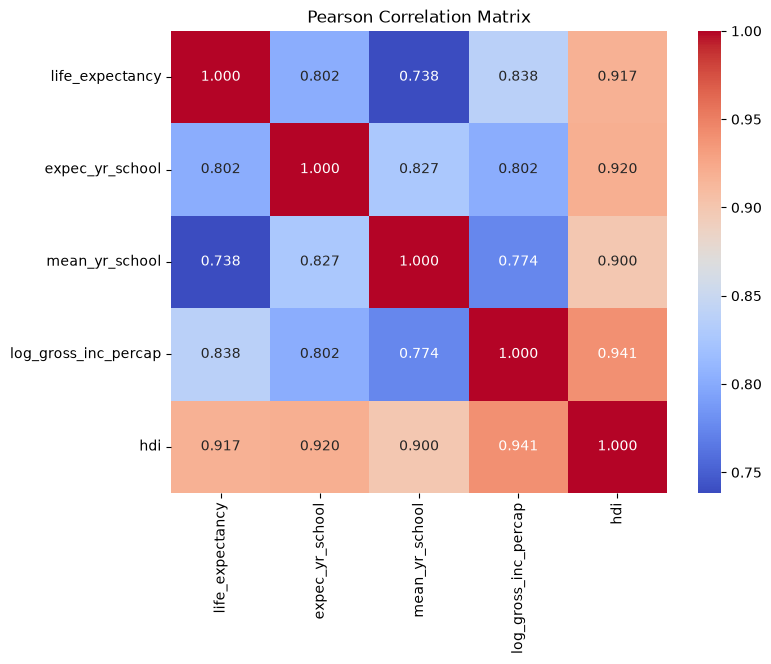

eda_report.md generated.


In [6]:
corr_matrix = df_clean[features + [target]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f")
plt.title('Pearson Correlation Matrix')
plt.show()

# Multicollinearity Analysis (VIF)
# To calculate VIF, we should add a constant term, but for relative comparison raw is okay
from statsmodels.tools.tools import add_constant
X_vif = add_constant(df_clean[features])
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

with open("reports/eda_report.md", "w") as f:
    f.write("# EDA and Statistical Justification\n\n")
    f.write("## Pearson Correlation Matrix\n")
    f.write(corr_matrix.to_markdown() + "\n\n")
    f.write("## Multicollinearity Analysis (VIF)\n")
    f.write(vif_data.to_markdown() + "\n\n")
    f.write("## Discussion\n")
    f.write("The variables show strong positive correlations with HDI. Since HDI is a composite index built from these exact indicators, multicollinearity is fundamentally expected and conceptually sound.\n")
print("eda_report.md generated.")

## Save Processed Data

In [1]:
os.makedirs("datasets/processed", exist_ok=True)
df_clean.to_csv("datasets/processed/hdi_cleaned.csv", index=False)
print("Cleaned dataset saved to datasets/processed/hdi_cleaned.csv")

NameError: name 'os' is not defined